# Ex. D1a: Supply Chain Optimization 

Adapted to the CDT context from the [original](https://github.com/onuryus/Supply_Chain_Optimization) version.

# Introduction

Supply chains are encountered in almost every field, and optimizing these processes can yield substantial financial benefits for businesses/companies. This chain encompasses the entire process from sourcing raw materials from suppliers, processing them in factories, storing them in warehouses, and finally delivering them to retailers. 

In the <mark>CCDS context</mark>, we can consider primary data sources (instruments), high performance computing centers for processing, data centers for storage, and finally data products delivered to end-users. Note that this is very similar to what is envisaged for the SKA Observatory - see [https://www.skao.int/en](https://www.skao.int/en)

# Objective

The objective of this study is to minimize costs within a supply chain model while meeting the demands of retailers. The model aims to ensure that products are delivered at the lowest possible cost by optimizing the flow of goods between suppliers, production centers, warehouses, and retailers.

We have 3 different suppliers, 3 production centers (factories), 3 warehouses, and 3 retailers. Each of these entities has distinct capacities and demands, as well as varying production, processing, storage, and sales costs.

<table>
<tr>
  <td>

  ### 1. Suppliers

  |  Supplier ID  |Production Capacity (tons)| Production Cost (USD/ton) |
  |---------------|--------------------------|---------------------------|
  | S1            | 5000                     | 10                        |
  | S2            | 6000                     | 12                        |
  | S3            | 4000                     | 11                        |

  </td>
  <td>

  ### 2. Production Centers (Factories)

  | Production Center ID | Capacity (tons) | Operating Cost (USD/ton) |
  |-------------------|----------------|---------------------------|
  | F1                | 7000           | 5                         |
  | F2                | 6000           | 6                         |
  | F3                | 5000           | 4                         |

  </td>
</tr>
<tr>
  <td>

  ### 3. Warehouses

  | Warehouses ID | Capacity (tons) | Storage Cost (USD/ton) |
  |---------|----------------|-----------------------------|
  | W1      | 3000           | 2                           |
  | W2      | 4000           | 3                           |
  | W3      | 5000           | 1.5                         |

  </td>
  <td>

  ### 4. Retailers
  
  | Retailers ID   | Demand (tons)| Sale Price (USD/ton) |
  |----------------|-------------|------------------------|
  | R1             | 4000        | 20                     |
  | R2             | 5000        | 18                     |
  | R3             | 6000        | 19                     |

  </td>
</tr>
</table>


In addition to the costs, transportation costs between each location also vary, and the cost data is presented in the table below

<table>
  <tr>
    <td>
      <table>
        <tr>
          <th>Supplier → Production Center</th>
          <th>F1</th>
          <th>F2</th>
          <th>F3</th>
        </tr>
        <tr>
          <td>S1</td>
          <td>3</td>
          <td>2.5</td>
          <td>3.5</td>
        </tr>
        <tr>
          <td>S2</td>
          <td>2</td>
          <td>2</td>
          <td>3</td>
        </tr>
        <tr>
          <td>S3</td>
          <td>3</td>
          <td>3.5</td>
          <td>2.5</td>
        </tr>
      </table>
    </td>
    <td>
      <table>
        <tr>
          <th>Production Center → WareHouse</th>
          <th>W1</th>
          <th>W2</th>
          <th>W3</th>
        </tr>
        <tr>
          <td>F1</td>
          <td>1.5</td>
          <td>2</td>
          <td>2.5</td>
        </tr>
        <tr>
          <td>F2</td>
          <td>2</td>
          <td>1.5</td>
          <td>2</td>
        </tr>
        <tr>
          <td>F3</td>
          <td>2.5</td>
          <td>2</td>
          <td>1.5</td>
        </tr>
      </table>
    </td>
    <td>
      <table>
        <tr>
          <th>WareHouse → Retailers </th>
          <th>R1</th>
          <th>R2</th>
          <th>R3</th>
        </tr>
        <tr>
          <td>W1</td>
          <td>1</td>
          <td>1.5</td>
          <td>2</td>
        </tr>
        <tr>
          <td>W2</td>
          <td>1.2</td>
          <td>1</td>
          <td>1.8</td>
        </tr>
        <tr>
          <td>W3</td>
          <td>1.5</td>
          <td>1.2</td>
          <td>1</td>
        </tr>
      </table>
    </td>
  </tr>
</table>


We impose quotas on the factories. Accordingly, Factory1 can only use 70% of its capacity, Factory2 can use 100%, and finally, Factory3 can utilize 85% of its capacity.

Here is a summary of the system, parameters, variables, constraints, and objective function.


**Sets:**

- $\mathcal{S}$: Suppliers Suppliers
- $\mathcal{F}$: Factories
- $\mathcal{W}$: Warehouses
- $\mathcal{R}$: Retailers

**Parameters:**

- $P_s$: Production capacity of supplier $s$ (tons)
- $C_s$: Production cost of supplier $s$ (USD/ton)
- $P_f$: Capacity of factory $f$ (tons)
- $O_f$: Operating cost of factory $f$ (USD/ton)
- $P_w$: Capacity of warehouse $w$ (tons)
- $S_w$: Storage cost for warehouse $w$ (USD/ton)
- $D_r$: Demand for retailer $r$ (tons)
- $T_{sf}$: Transportation cost between supplier $s$ and factory $f$ (USD/ton)
- $T_{fw}$: Transportation cost between factory $f$ and warehouse $w$ (USD/ton)
- $T_{wr}$: Transportation cost between warehouse $w$ and retailer $r$ (USD/ton)



**Variables:**

- $x_{sf}$: Raw materials sent from supplier $s$ to factory $f$ (tons)
- $y_{fw}$: Products sent from factory $f$ to warehouse $w$ (tons)
- $z_{wr}$: Products sent from warehouse $w$ to retailer $r$ (tons)

## Objective Function
The goal is to minimize the total cost:

$$
\text{Minimize} \ Z = \sum_{s \in S} \sum_{f \in F} C_s \cdot x_{sf} + \sum_{f \in F} \sum_{w \in W} O_f \cdot y_{fw} + \sum_{w \in W} \sum_{r \in R} S_w \cdot z_{wr} + \sum_{s \in S} \sum_{f \in F} T_{sf} \cdot x_{sf} + \sum_{f \in F} \sum_{w \in W} T_{fw} \cdot y_{fw} + \sum_{w \in W} \sum_{r \in R} T_{wr} \cdot z_{wr}
$$

## Constraints
1. **Supplier Capacity Constraints**:
   The total raw materials sent by each supplier must not exceed its production capacity:
   $$
   \sum_{f \in F} x_{sf} \leq P_s, \quad \forall s \in S.
   $$

2. **Factory Capacity Constraints**:
   The amount of raw materials received by each factory must not exceed its capacity. Additionally, the operating rate of each factory is restricted to a specific percentage:
   $$
   \sum_{s \in S} x_{sf} \leq P_f, \quad \forall f \in F.
   $$

   
- $F_1$:  $\sum_{s \in S} x_{sf_1} \le 0.7  P_1$
- $F_2$:  $\sum_{s \in S} x_{sf_2} \le 1.0  P_2$
- $F_3$:  $\sum_{s \in S} x_{sf_3} \le 0.85  P_3$

  
3. **Warehouse Capacity Constraints**:
   The amount of products received by each warehouse must not exceed its capacity:
   $$
   \sum_{f \in F} y_{fw} \leq P_w, \quad \forall w \in W
   $$

4. **Retailer Demand Constraints**:
   The demand of each retailer must be met by the products received from the corresponding warehouse:
   $$
   \sum_{w \in W} z_{wr} = D_r, \quad \forall r \in R
   $$

5. **Factory Input-Output Balance**:
   There must be a balance between the incoming and outgoing products for each factory:
   $$
   \sum_{s \in S} x_{sf} = \sum_{w \in W} y_{fw}, \quad \forall f \in F
   $$

6. **Warehouse Input-Output Balance**:
   There must be a balance between the incoming and outgoing products for each warehouse:
   $$
   \sum_{f \in F} y_{fw} = \sum_{r \in R} z_{wr}, \quad \forall w \in W
   $$


## Code

### Optimization Section

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
from pyomo.environ import *

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import numpy as np

In [3]:

model = ConcreteModel()

# Sets
model.suppliers = Set(initialize=['S1', 'S2', 'S3'])
model.factories = Set(initialize=['F1', 'F2', 'F3'])
model.warehouses = Set(initialize=['W1', 'W2', 'W3'])
model.retailers = Set(initialize=['R1', 'R2', 'R3'])

# Parameters
model.production_capacity = Param(model.suppliers, initialize={'S1': 10000, 'S2': 12000, 'S3': 8000})
model.production_cost = Param(model.suppliers, initialize={'S1': 10, 'S2': 12, 'S3': 11})
model.factory_capacity = Param(model.factories, initialize={'F1': 10000, 'F2': 9000, 'F3': 8000})
model.operating_cost = Param(model.factories, initialize={'F1': 5, 'F2': 6, 'F3': 4})
model.warehouse_capacity = Param(model.warehouses, initialize={'W1': 6000, 'W2': 8000, 'W3': 10000})
model.storage_cost = Param(model.warehouses, initialize={'W1': 2, 'W2': 3, 'W3': 1.5})
model.demand = Param(model.retailers, initialize={'R1': 4000, 'R2': 5000, 'R3': 6000})

# Transportation Cost
model.transport_cost = {
    ('S1', 'F1'): 3,   ('S1', 'F2'): 2.5, ('S1', 'F3'): 3.5,
    ('S2', 'F1'): 2,   ('S2', 'F2'): 2,   ('S2', 'F3'): 3,
    ('S3', 'F1'): 3,   ('S3', 'F2'): 3.5, ('S3', 'F3'): 2.5,
    ('F1', 'W1'): 1.5, ('F1', 'W2'): 2,   ('F1', 'W3'): 2.5,
    ('F2', 'W1'): 2,   ('F2', 'W2'): 1.5, ('F2', 'W3'): 2,
    ('F3', 'W1'): 2.5, ('F3', 'W2'): 2,   ('F3', 'W3'): 1.5,
    ('W1', 'R1'): 1,   ('W1', 'R2'): 1.5, ('W1', 'R3'): 2,
    ('W2', 'R1'): 1.2, ('W2', 'R2'): 1,   ('W2', 'R3'): 1.8,
    ('W3', 'R1'): 1.5, ('W3', 'R2'): 1.2, ('W3', 'R3'): 1,
}

# Variables
model.x = Var(model.suppliers, model.factories, domain=NonNegativeReals)  # from supplier to factory
model.y = Var(model.factories, model.warehouses, domain=NonNegativeReals)  # from factory to warehouse
model.z = Var(model.warehouses, model.retailers, domain=NonNegativeReals)  # from warehouse to retailer

# Objective Function: Minimize Total Cost
def total_cost(model):
    return (sum(model.production_cost[s] * model.x[s, f] for s in model.suppliers for f in model.factories) +
            sum(model.operating_cost[f] * model.y[f, w] for f in model.factories for w in model.warehouses) +
            sum(model.storage_cost[w] * model.z[w, r] for w in model.warehouses for r in model.retailers) +
            sum(model.transport_cost[s, f] * model.x[s, f] for s in model.suppliers for f in model.factories) +
            sum(model.transport_cost[f, w] * model.y[f, w] for f in model.factories for w in model.warehouses) +
            sum(model.transport_cost[w, r] * model.z[w, r] for w in model.warehouses for r in model.retailers))

model.obj = Objective(rule=total_cost, sense=minimize)

# Constraints
# Production Capacity Constraints
def supply_capacity_rule(model, s):
    return sum(model.x[s, f] for f in model.factories) <= model.production_capacity[s]
model.supply_capacity_constraint = Constraint(model.suppliers, rule=supply_capacity_rule)

# Factory Capacity Constraints
def factory_capacity_rule(model, f):
    return sum(model.x[s, f] for s in model.suppliers) <= model.factory_capacity[f]
model.factory_capacity_constraint = Constraint(model.factories, rule=factory_capacity_rule)

# Special Capacity Constraints of Factories
def factory_capacity_limit_rule(model, f):
    if f == 'F1':
        return sum(model.x[s, f] for s in model.suppliers) <= 0.7 * model.factory_capacity[f]  # F1  %70
    elif f == 'F2':
        return sum(model.x[s, f] for s in model.suppliers) <= 1.0 * model.factory_capacity[f]  # F2  %100
    elif f == 'F3':
        return sum(model.x[s, f] for s in model.suppliers) <= 0.85 * model.factory_capacity[f]  # F3  %85
model.factory_capacity_limit_constraint = Constraint(model.factories, rule=factory_capacity_limit_rule)

# Warehouse Capacity Constraints
def warehouse_capacity_rule(model, w):
    return sum(model.y[f, w] for f in model.factories) <= model.warehouse_capacity[w]
model.warehouse_capacity_constraint = Constraint(model.warehouses, rule=warehouse_capacity_rule)

# Retailer Demand Constraints
def retailer_demand_rule(model, r):
    return sum(model.z[w, r] for w in model.warehouses) == model.demand[r]
model.retailer_demand_constraint = Constraint(model.retailers, rule=retailer_demand_rule)

# Factory Inflow-Outflow Balance
def factory_balance_rule(model, f):
    return sum(model.x[s, f] for s in model.suppliers) == sum(model.y[f, w] for w in model.warehouses)
model.factory_balance_constraint = Constraint(model.factories, rule=factory_balance_rule)

# Warehouse Inflow-Outflow Balance
def warehouse_balance_rule(model, w):
    return sum(model.y[f, w] for f in model.factories) == sum(model.z[w, r] for r in model.retailers)
model.warehouse_balance_constraint = Constraint(model.warehouses, rule=warehouse_balance_rule)

solver = SolverFactory('glpk')
results = solver.solve(model)

model.display()


Model unknown

  Variables:
    x : Size=9, Index=suppliers*factories
        Key          : Lower : Value  : Upper : Fixed : Stale : Domain
        ('S1', 'F1') :     0 : 7000.0 :  None : False : False : NonNegativeReals
        ('S1', 'F2') :     0 : 1200.0 :  None : False : False : NonNegativeReals
        ('S1', 'F3') :     0 :    0.0 :  None : False : False : NonNegativeReals
        ('S2', 'F1') :     0 :    0.0 :  None : False : False : NonNegativeReals
        ('S2', 'F2') :     0 :    0.0 :  None : False : False : NonNegativeReals
        ('S2', 'F3') :     0 :    0.0 :  None : False : False : NonNegativeReals
        ('S3', 'F1') :     0 :    0.0 :  None : False : False : NonNegativeReals
        ('S3', 'F2') :     0 :    0.0 :  None : False : False : NonNegativeReals
        ('S3', 'F3') :     0 : 6800.0 :  None : False : False : NonNegativeReals
    y : Size=9, Index=factories*warehouses
        Key          : Lower : Value  : Upper : Fixed : Stale : Domain
        ('F1', '

### Graph Section

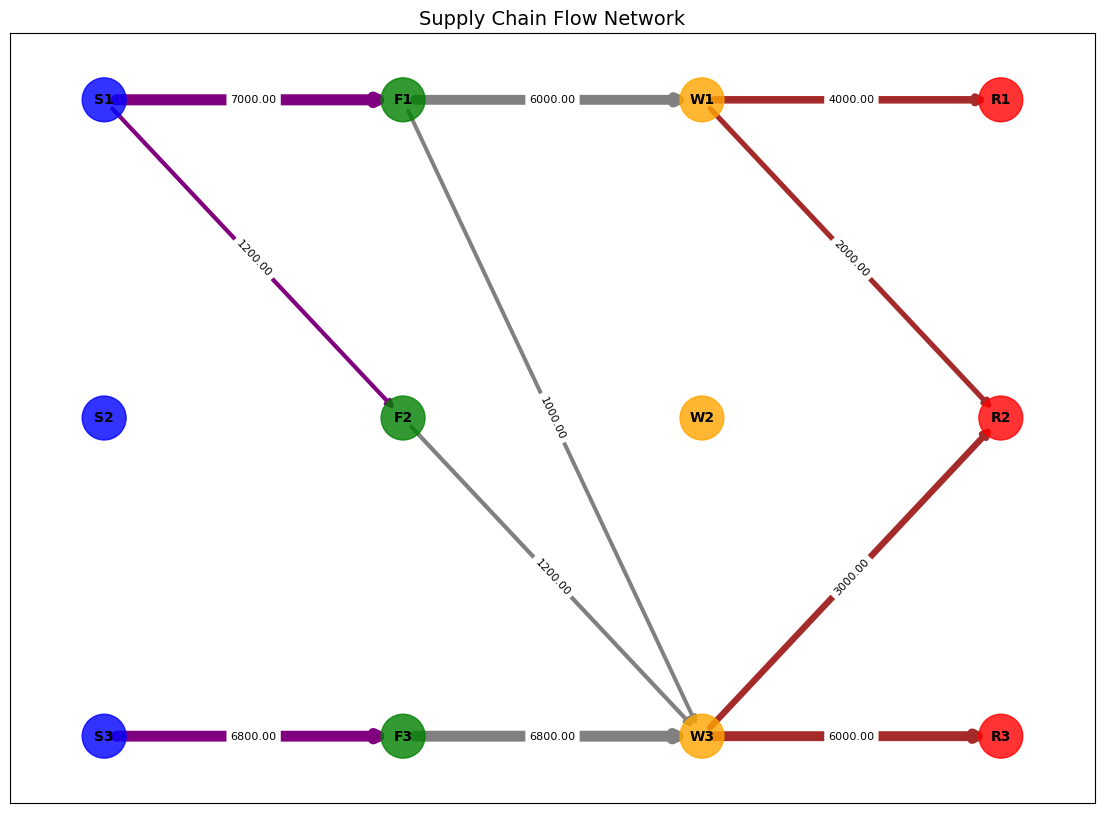

In [4]:
G = nx.DiGraph()

supplier_color, factory_color, warehouse_color, retailer_color = 'blue', 'green', 'orange', 'red'
node_size = 1000

for s in model.suppliers:
    G.add_node(s, color=supplier_color, size=node_size)

for f in model.factories:
    G.add_node(f, color=factory_color, size=node_size)

for w in model.warehouses:
    G.add_node(w, color=warehouse_color, size=node_size)

for r in model.retailers:
    G.add_node(r, color=retailer_color, size=node_size)

# Flow and cost information for edge labels
max_flow = max([model.x[s, f].value for s in model.suppliers for f in model.factories] +
               [model.y[f, w].value for f in model.factories for w in model.warehouses] +
               [model.z[w, r].value for w in model.warehouses for r in model.retailers])

for s in model.suppliers:
    for f in model.factories:
        if model.x[s, f].value > 0:
            flow = model.x[s, f].value
            G.add_edge(s, f, weight=flow, label=f'{flow:.2f}', color='purple', 
                       linewidth=2 + 6 * (flow / max_flow))

for f in model.factories:
    for w in model.warehouses:
        if model.y[f, w].value > 0:
            flow = model.y[f, w].value
            G.add_edge(f, w, weight=flow, label=f'{flow:.2f}', color='gray', 
                       linewidth=2 + 6 * (flow / max_flow))

for w in model.warehouses:
    for r in model.retailers:
        if model.z[w, r].value > 0:
            flow = model.z[w, r].value
            G.add_edge(w, r, weight=flow, label=f'{flow:.2f}', color='brown', 
                       linewidth=2 + 6 * (flow / max_flow))

# Node
pos = {
    'S1': (0, 2), 'S2': (0, 1), 'S3': (0, 0),
    'F1': (1, 2), 'F2': (1, 1), 'F3': (1, 0),
    'W1': (2, 2), 'W2': (2, 1), 'W3': (2, 0),
    'R1': (3, 2), 'R2': (3, 1), 'R3': (3, 0),
}

node_colors = [G.nodes[node]['color'] for node in G.nodes]
node_sizes = [G.nodes[node]['size'] for node in G.nodes]

edge_colors = [G[u][v]['color'] for u, v in G.edges()]
edge_widths = [G[u][v]['linewidth'] for u, v in G.edges()]

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, arrows=True)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color='black')

plt.title("Supply Chain Flow Network", fontsize=14)# fontweight='bold')

plt.show()
